In [3]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Lancement pour Graphes .graphml

In [4]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

In [56]:
G_name_list = ["reel_facebook_friends"]

for G_name in G_name_list : 
    G = load_graphml_safe(f"graph_library/{G_name}.graphml")
    G_train_with_structure = gp.computeStructureFeatures(G)
    G_train_with_communities = gp.computeCommunityFeatures(G_train_with_structure)
    print("fini! tot")
    G_train_with_distances = gp.computeDistanceFeatures(G_train_with_communities)
    print("fini!")
    gp.loadsave_data_joblib(data=G_train_with_distances, filename=f"G_train_w_struct_com_dist_{G_name}", mode="save", talk=True)

✅ Graphe chargé : 362 nœuds et 1988 liens.

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...
fini! tot

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:01<00:00, 20.31it/s]


Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:01<00:00, 15.68it/s]


Entraînement du modèle Skip-gram...
fini!
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_reel_facebook_friends


Erreur : Le fichier n'existe pas : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_hidden_reel_Airports
SHAP Analysis introuvable pour reel_Airports.
{513: 473, 75: 10, 638: 13, 253: 6, 996: 242, 1895: 4, 633: 20, 238: 112, 663: 4, 1641: 170, 2382: 234, 766: 83, 166: 6, 2498: 151, 1150: 87, 1569: 193, 2758: 6, 2603: 47, 689: 82, 3138: 6, 1315: 9, 2583: 8, 1667: 11, 1066: 16, 1420: 126, 3036: 156, 1272: 163, 1248: 9, 2702: 122, 3066: 82, 1020: 73, 344: 153, 2167: 96, 814: 59, 2827: 60, 3140: 152, 387: 37, 2436: 82}
Récapitulatif des tailles :
Communauté 513 : 14.06% % des nœuds (473 nœuds)
Communauté 996 : 7.20% % des nœuds (242 nœuds)
Communauté 2382 : 6.96% % des nœuds (234 nœuds)
Communauté 1569 : 5.74% % des nœuds (193 nœuds)
Communauté 1641 : 5.06% % des nœuds (170 nœuds)
Communauté 1272 : 4.85% % des nœuds (163 nœuds)
Communauté 3036 : 4.64% % des nœuds (156 nœuds)
Communauté 344 : 4.55% % des nœuds (153 nœuds)
Communauté 3140 : 4.52%

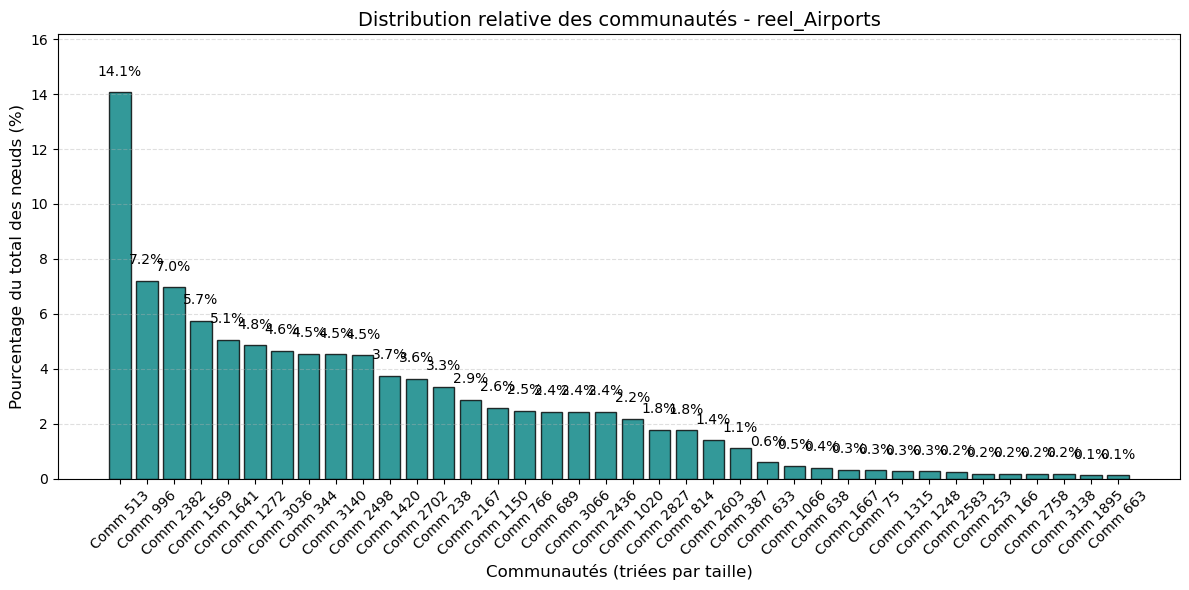

In [38]:
G_name = "reel_Airports"

G_train, data_train, _, _,_,_ = gp.load_all_data_for_graph(G_name)
all_densities = gp.prepare_all_densities(G_train)

communities = nx.get_node_attributes(G_train, 'sbm_id')
counts = {}

for node, comm in communities.items():
    counts[comm] = counts.get(comm, 0) + 1

print(counts)

prob_matrix = all_densities['sbm']

import matplotlib.pyplot as plt

# 1. Calcul des données relatives
total_nodes = G_train.number_of_nodes()
# On trie par taille décroissante pour le graphique également
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [f"Comm {c}" for c, s in sorted_counts]
percentages = [(s / total_nodes) * 100 for c, s in sorted_counts]

# 2. Affichage textuel (votre code)
print("Récapitulatif des tailles :")
for comm, size in sorted_counts:
    print(f"Communauté {comm} : {size/total_nodes:.2%} % des nœuds ({size} nœuds)")

print(f"\nTotal : {total_nodes} nœuds")

# 3. Visualisation de la distribution relative
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, percentages, color='teal', edgecolor='black', alpha=0.8)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title(f"Distribution relative des communautés - {G_name}", fontsize=14)
plt.ylabel("Pourcentage du total des nœuds (%)", fontsize=12)
plt.xlabel("Communautés (triées par taille)", fontsize=12)
plt.ylim(0, max(percentages) * 1.15) # Laisser de la place pour les labels
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Chargement du graphe 'facebook_friends'...
Nodes: 362
Edges: 1988
✅ Graphe sauvegardé avec succès sous : graph_library/reel_facebook_friends.graphml


## 2 - Lancement pour graphes sbm_ratio

In [5]:
list_i = [1.00, 0.00]

for i in np.arange(0.00, 1.25, 0.25):
#for i in list_i:
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbmv2_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")

    gp.execute(G, G_name, "shap")

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbmv2_0_00_pos_1_00
Graphe chargé avec succès : 362 nœuds et 1966 liens.

 [SHAP] Shapley va ! Lu.
 Chargement des données pré-calculées...
Calcul TreeExplainer : 590 échantillons au total.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Sauvegarde de l'analyse SHAP
######################################
#### graph sbm 0.25 pos 0.75 ####
######################################
artificial_graph_sbmv2_0_25_pos_0_75
Graphe chargé avec succès : 362 nœuds et 1969 liens.

 [SHAP] Shapley va ! Lu.
 Chargement des données pré-calculées...
Calcul TreeExplainer : 592 échantillons au total.
Sauvegarde de l'analyse SHAP


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


######################################
#### graph sbm 0.50 pos 0.50 ####
######################################
artificial_graph_sbmv2_0_50_pos_0_50
Graphe chargé avec succès : 362 nœuds et 2003 liens.

 [SHAP] Shapley va ! Lu.
 Chargement des données pré-calculées...
Calcul TreeExplainer : 602 échantillons au total.
Sauvegarde de l'analyse SHAP
######################################
#### graph sbm 0.75 pos 0.25 ####
######################################
artificial_graph_sbmv2_0_75_pos_0_25
Graphe chargé avec succès : 362 nœuds et 1997 liens.

 [SHAP] Shapley va ! Lu.
 Chargement des données pré-calculées...
Calcul TreeExplainer : 600 échantillons au total.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Sauvegarde de l'analyse SHAP
######################################
#### graph sbm 1.00 pos 0.00 ####
######################################
artificial_graph_sbmv2_1_00_pos_0_00
Graphe chargé avec succès : 362 nœuds et 1985 liens.

 [SHAP] Shapley va ! Lu.
 Chargement des données pré-calculées...
Calcul TreeExplainer : 596 échantillons au total.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Sauvegarde de l'analyse SHAP
